## Relu Turevi Nedir ?


The ReLU (Rectified Linear Unit) activation function is defined by the formula:

$f(x) = \max(0, x)$

This means:
*   If $x > 0$, then $f(x) = x$
*   If $x \le 0$, then $f(x) = 0$

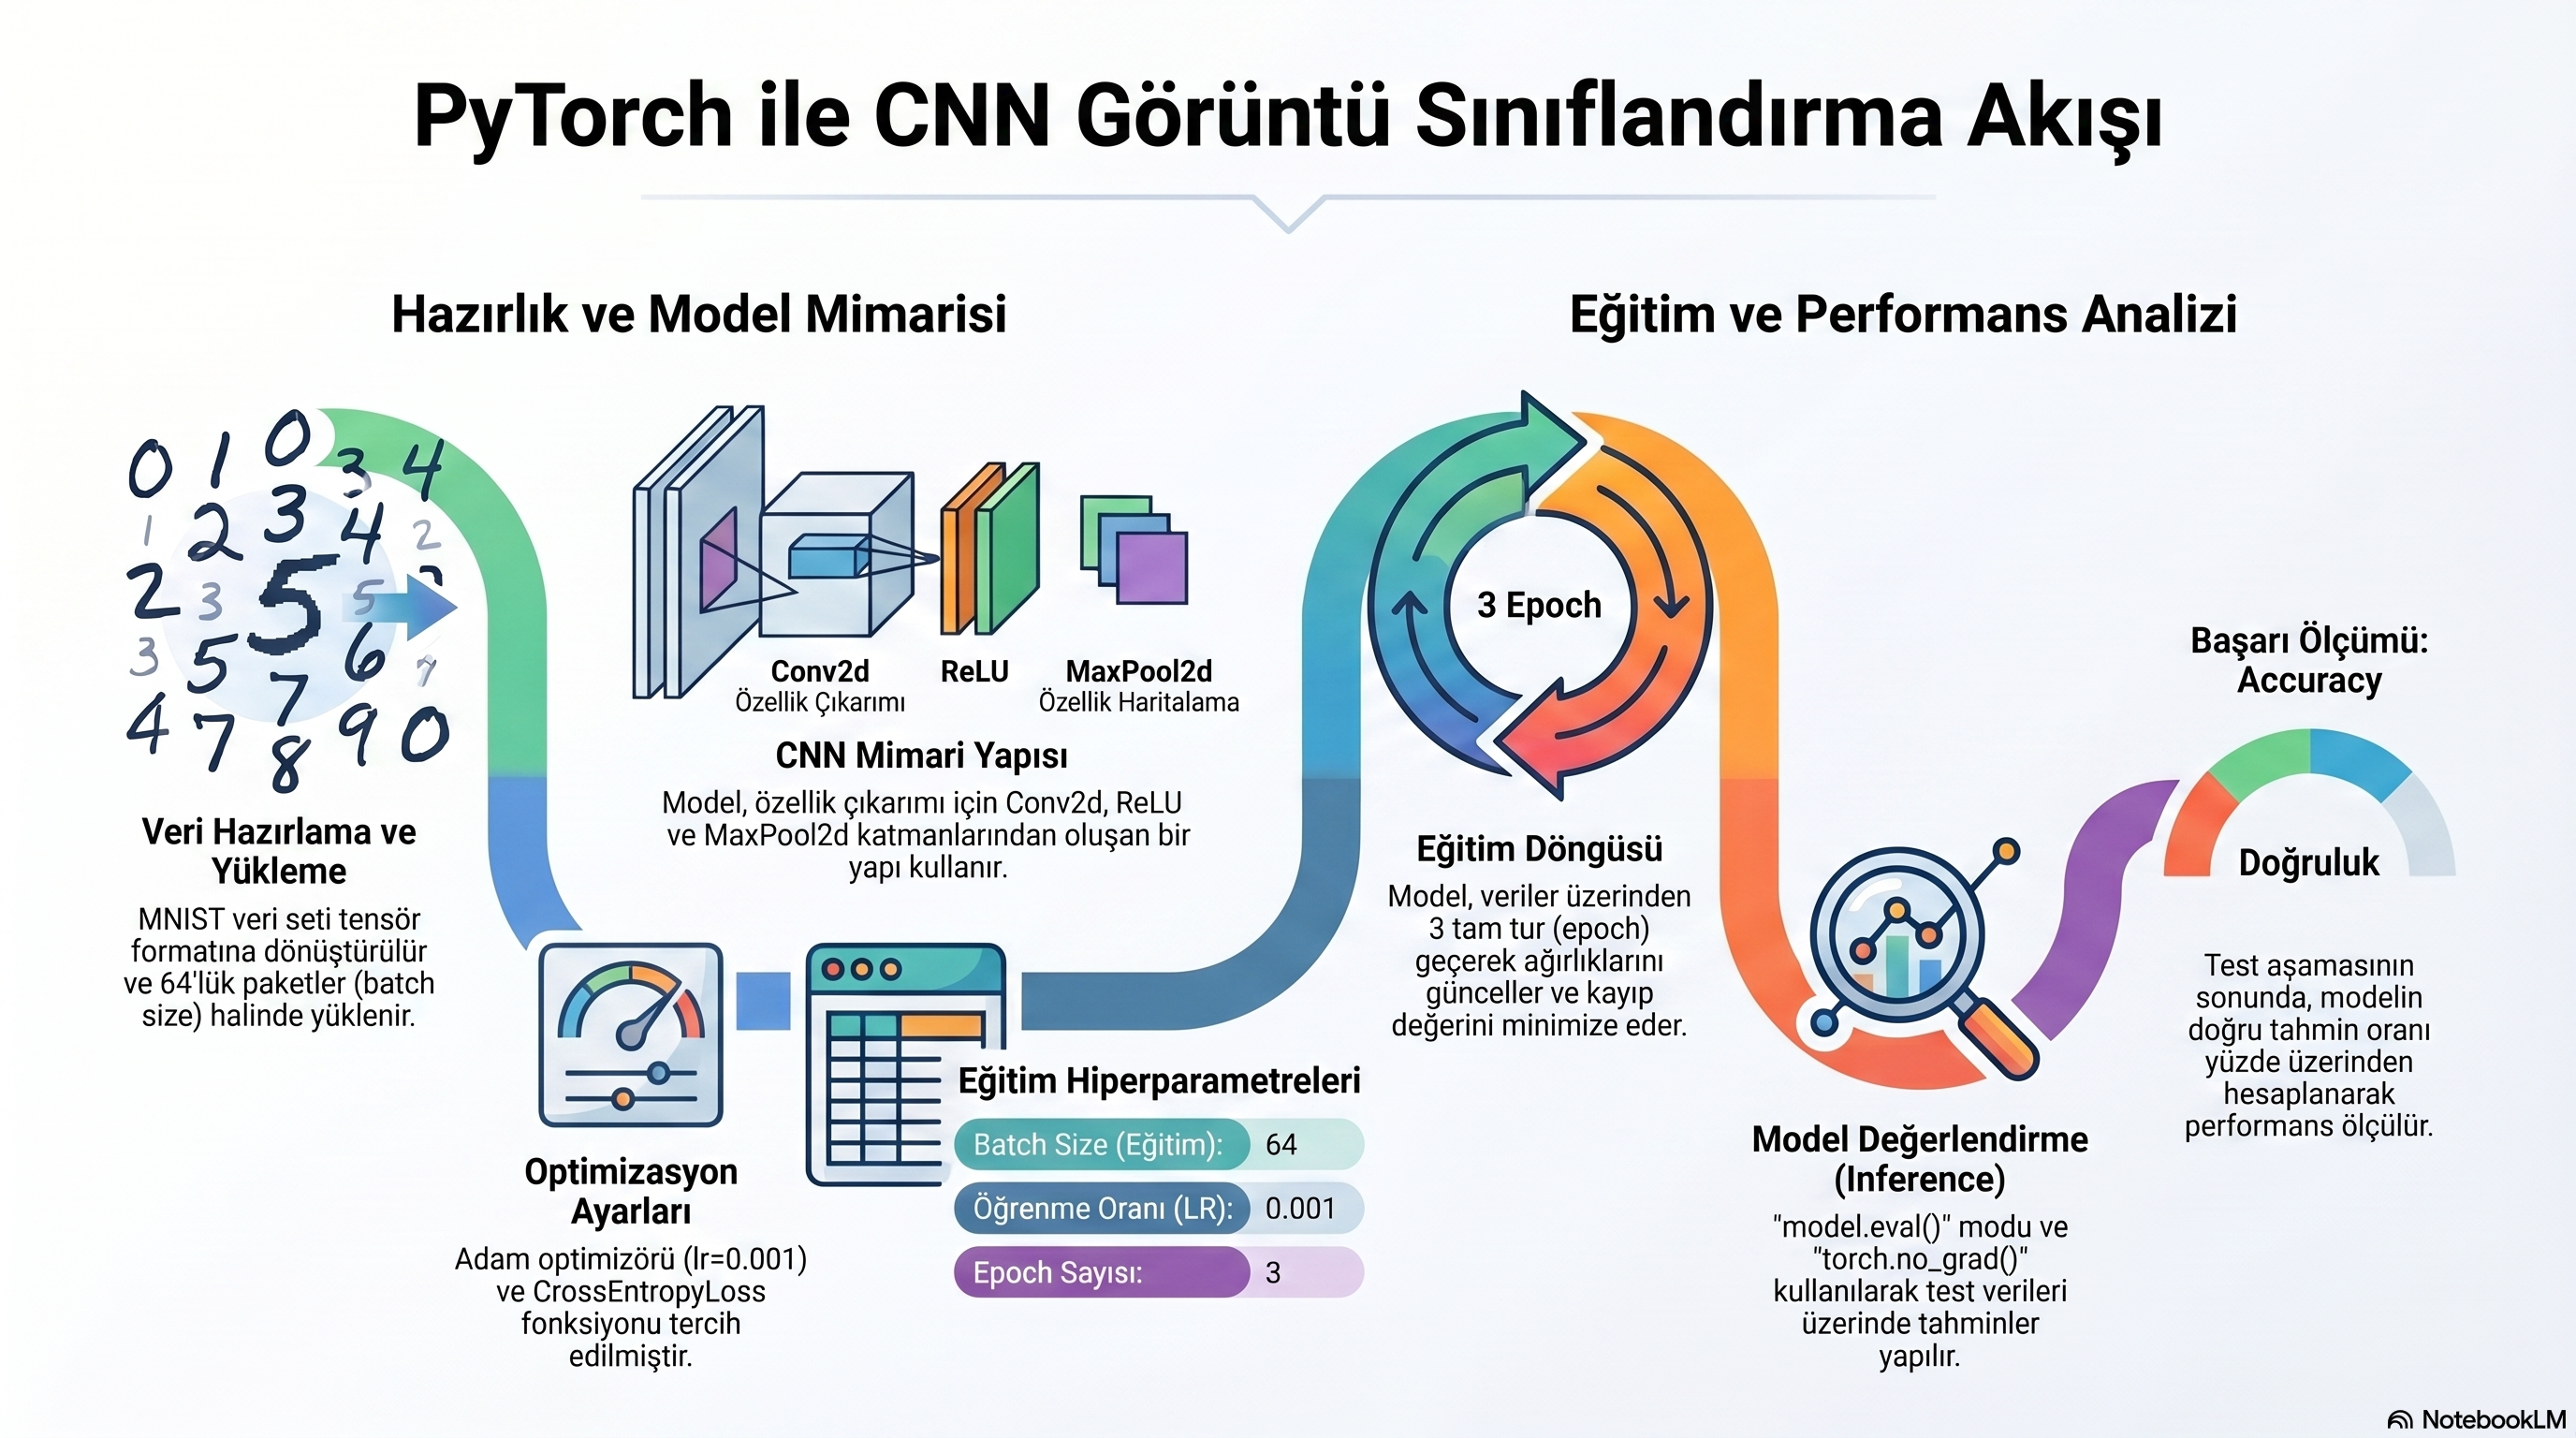

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor,Normalize,Compose
import matplotlib.pyplot as plt
from IPython.display import display, update_display


In [ ]:
transform = Compose([
    ToTensor(),
    Normalize((0.1307,),(0.3081,))
])


train_dataset = MNIST(
    root = './data',
    train = True,
    transform= transform ,
    download = True
)

train_dataset

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.85MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [ ]:
test_dataset = MNIST(
    root = './data',
    train = False,
    transform= transform,
    download=True
)
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Egitim veri seti : {len(train_loader)}")
print(f"Test veri seti   : {len(test_loader)}")

Egitim veri seti : 1875
Test veri seti   : 313


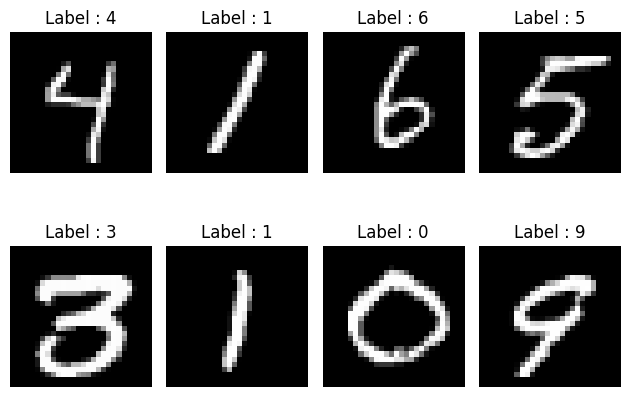

In [ ]:
i = iter(train_loader)
imgs,lbls = next(i)
# img = imgs[0].squeeze().numpy()
# plt.imshow(img,cmap='gray')
# plt.axis(False)
fig,axs = plt.subplots(2,4)

# 1,28,28 --> 28,28
for i,ax in enumerate(axs.flatten()):
    img = imgs[i].squeeze().numpy()
    lbl = lbls[i].item()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label : {lbl}')
    ax.set_axis_off()

plt.tight_layout()

## Batch Normalization ve Dropout Kavramları

### 1. Batch Normalization (Toplu Normalizasyon)
Batch Normalization, derin sinir ağlarının eğitimini hızlandırmak ve daha kararlı hale getirmek için kullanılan bir tekniktir.

*   **Nasıl Çalışır?**: Her katmanın girdilerini, o eğitim grubunun (mini-batch) ortalamasını ve varyansını kullanarak normalize eder.
*   **Avantajları**:
    *   Eğitim süresini kısaltır (daha yüksek öğrenme oranlarına izin verir).
    *   İçsel değişken kayması (Internal Covariate Shift) sorununu azaltır.
    *   Hafif bir regülasyon etkisi yaratarak aşırı öğrenmeyi (overfitting) engellemeye yardımcı olur.

### 2. Dropout (Seyreltme)
Dropout, sinir ağlarında aşırı öğrenmeyi (overfitting) önlemek için kullanılan en yaygın regülasyon tekniklerinden biridir.

*   **Nasıl Çalışır?**: Eğitim sırasında, her adımda belirlenen bir olasılığa göre (örneğin %50) bazı nöronları rastgele olarak 'kapatır' (çıktısını sıfır yapar).
*   **Avantajları**:
    *   Nöronların birbirine aşırı bağımlı hale gelmesini (co-adaptation) engeller.
    *   Ağın daha genel ve sağlam (robust) özellikler öğrenmesini sağlar.
    *   Test aşamasında tüm nöronlar kullanılır, ancak ağırlıklar Dropout oranına göre ölçeklenir.

### Nöronların Co-Adaptation (Birlikte Adaptasyon) Mekanizması

Matematiksel olarak bir katmandaki çıktıyı $h = \sigma(Wx)$ olarak düşünürsek, eğitim sırasında ağırlık güncellemeleri $(\Delta W)$ kayıp fonksiyonunun ($L$) gradyanına dayanır:

$$\Delta w_{ij} = -\eta \frac{\partial L}{\partial w_{ij}}$$

**Aşırı Bağımlılık (Co-adaptation) Süreci:**

1.  **Hata Telafisi:** Eğer bir nöron ($n_1$) belirli bir özelliği yanlış öğrenirse veya gürültülü bir çıktı üretirse, ağın toplam kaybını ($L$) minimize etmek için yanındaki diğer nöronlar ($n_2, n_3, ...$) bu hatayı 'iptal edecek' veya 'telafi edecek' yönde ağırlıklarını günceller.
2.  **Gradyan Etkileşimi:** Zincir kuralı gereği, bir katmandaki gradyanlar birbirine bağlıdır. Eğer nöronlar bağımsız özellikler öğrenmek yerine birbirlerinin çıktılarına göre şekillenirse, $\frac{\partial L}{\partial w_{n1}}$ ve $\frac{\partial L}{\partial w_{n2}}$ arasında yüksek korelasyon oluşur.
3.  **Karmaşık Bağımlılıklar:** Sonuçta, $n_2$ nöronu sadece girdi verisindeki ($x$) bir özelliği değil, aynı zamanda $n_1$'in o anki spesifik (ve muhtemelen hatalı) çıktısını da 'bekleyen' bir yapıya bürünür.

**Dropout Neden Çözer?**

Dropout uygulandığında, her eğitim adımında nöronların bir kısmı rastgele sıfırlanır ($r \in \{0, 1\}$ maskesi ile):

$$h_{dropout} = \sigma(Wx) \odot r$$

Bu durum, bir nöronun ($n_2$), diğer bir nöronun ($n_1$) orada olacağına güvenmesini engeller. Matematiksel olarak, her nöron tek başına (veya farklı rastgele alt kümelerle birlikte) faydalı bir özellik üretmeye zorlanır. Bu da nöronlar arasındaki yüksek korelasyonu (co-adaptation) kırarak daha 'genellenebilir' (robust) özelliklerin öğrenilmesini sağlar.

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self,input_size = 28*28, num_classes =10 ):

        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten() # Gelen bilgileri
        self.layer1 = nn.Linear(input_size, 256) #W.x + b = out
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()                    # a(out)
        self.dropout1 = nn.Dropout(0.5)


        self.layer2 = nn.Linear(256,512)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)

        self.layer3 = nn.Linear(512, num_classes)

    def forward(self,X):    # 32,1,28,28
        X = self.flatten(X) # 32,784
        # Layer1 islemleri
        out = self.layer1(X)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        # Layer2 islemleri
        out = self.layer2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        # Layer3 islemleri
        out = self.layer3(out) # 10 noron icin 10 tahmin
        return out

model = NeuralNetwork()

# i = iter(train_loader)
# imgs,lbls = next(i)
# pred = model(imgs)[0]
# torch.argmax(pred).item()

In [ ]:
# hiper parametre optimizas
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=2)

In [ ]:
for name,_ in model.named_parameters():
    print(name)

layer1.weight
layer1.bias
bn1.weight
bn1.bias
layer2.weight
layer2.bias
layer3.weight
layer3.bias


### F-Skoru ve Temel Metrikler Nedir?

Sınıflandırma modellerinde başarının sadece **Accuracy (Doğruluk)** ile ölçülmesi bazen yanıltıcı olabilir. Bu nedenle F-Skoru ve onu oluşturan metrikler kullanılır:

1. **Precision (Kesinlik):** Modelin 'pozitif' olarak tahmin ettiği değerlerin ne kadarının gerçekten pozitif olduğudur.
   * *Formül:* $TP / (TP + FP)$
   * *Örnek:* Model bir resme '7' dediyse, bunun gerçekten '7' olma olasılığıdır.

2. **Recall (Duyarlılık/Geri Çağırma):** Gerçekte 'pozitif' olan değerlerin ne kadarının model tarafından doğru tahmin edildiğidir.
   * *Formül:* $TP / (TP + FN)$
   * *Örnek:* Veri setindeki tüm '7' rakamlarının kaç tanesini yakalayabildik?

3. **F1-Score:** Precision ve Recall değerlerinin harmonik ortalamasıdır. İki metrik arasındaki dengeyi temsil eder.
   * *Formül:* $2 * (Precision * Recall) / (Precision + Recall)$

**Neden Önemlidir?**
Özellikle sınıfların dengesiz dağıldığı durumlarda (örneğin bir rakamın diğerlerinden çok daha az olması), modelin sadece baskın sınıfı tahmin ederek yüksek 'Accuracy' almasını engeller ve modelin tüm sınıfları ne kadar iyi öğrendiğini gösterir.

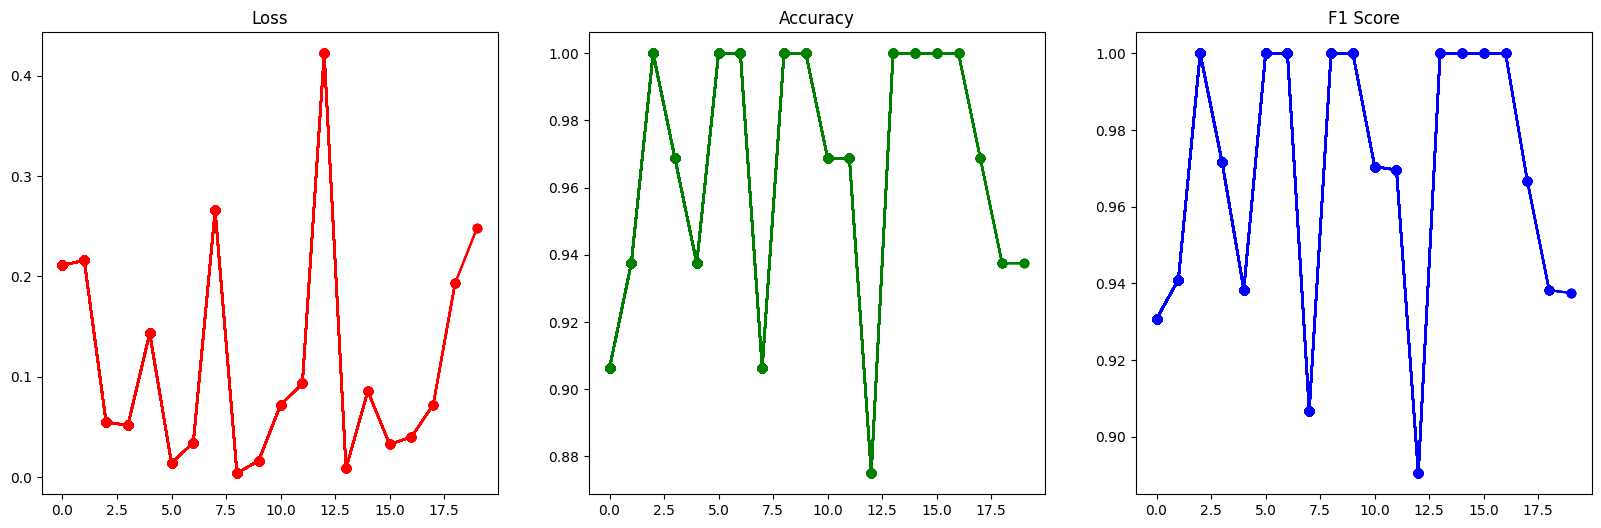

KeyboardInterrupt: 

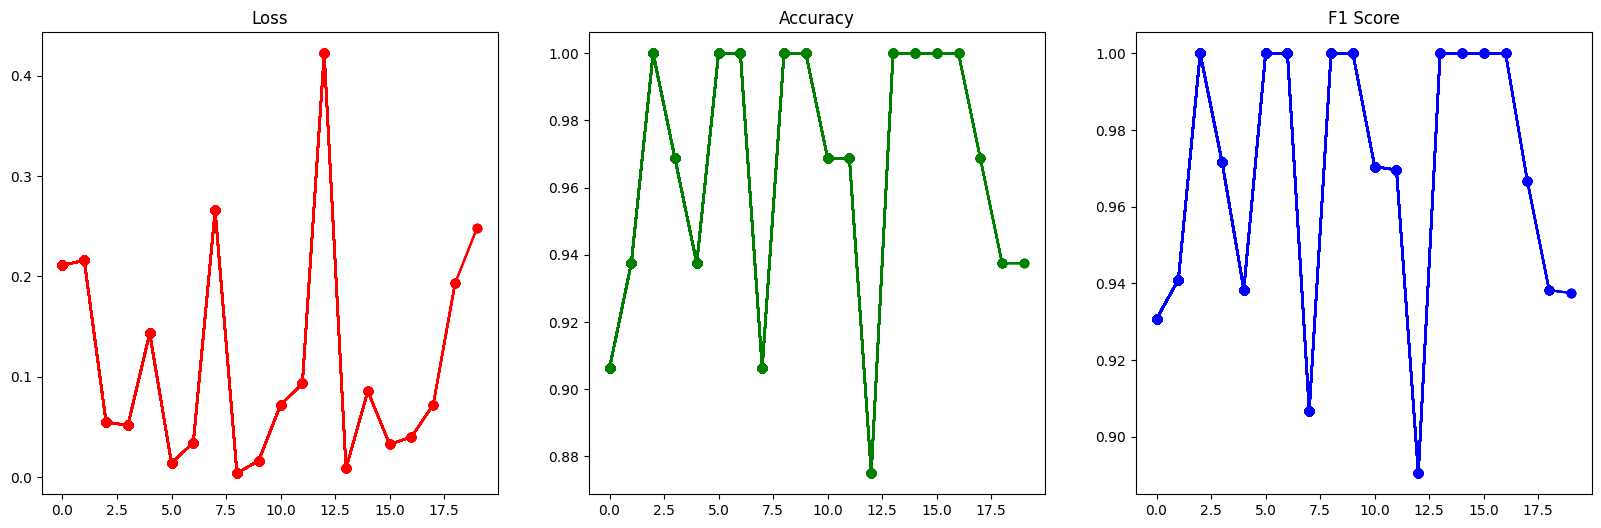

In [ ]:
from sklearn.metrics import f1_score

def train_loop(model, train_loader, loss_fn, optimizer, epochs=1):
    model.train()
    loss_list,acc_list,f1_list = [],[],[]
    v = 60


    fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(20,6))
    handle = display(fig,display_id=True)

    for epoch in range(epochs):
        for i,(images,labels) in enumerate(train_loader):
            preds = model(images) #32,1,28,28 -> [1...32]
            loss = loss_fn(preds, labels)

            optimizer.zero_grad()
            loss.backward()      # dw,db
            optimizer.step()     # W = W-dw b = b-db

            preds = torch.argmax(preds,dim=1)
            correct = (preds == labels).float().mean().item()
            f_score = f1_score(labels,preds,average='weighted')

            l = len(loss_list)
            if l < v:
                ax1.plot(range(len(loss_list)), loss_list, 'r-o')
                ax2.plot(range(len(acc_list)), acc_list,'g-o')
                ax3.plot(range(len(f1_list)), f1_list,'b-o')

            else:
                ax1.cla()
                ax2.cla()
                ax3.cla()

                ax1.plot(range(v), loss_list[l-v:], 'r-o')
                ax2.plot(range(v), acc_list[l-v:],'g-o')
                ax3.plot(range(v), f1_list[l-v:],'b-o')

            ax1.set_title('Loss')
            ax2.set_title('Accuracy')
            ax3.set_title('F1 Score')

            if i % 10 == 0:
                loss_list.append(loss.item())
                acc_list.append(correct)
                f1_list.append(f_score)

            if i == 300:
                break

            update_display(fig,display_id=handle.display_id)


        plt.close(fig)

train_loop(model,train_loader,loss_fn, optimizer,epochs=1)

In [ ]:
from sklearn.metrics import confusion_matrix as cm

def test_loop(model,test_loader):
    model.eval()
    all_preds ,all_labels = [], []

    with torch.no_grad():
        for i,(images,labels) in enumerate(test_loader):
            preds = model(images)
            preds = torch.argmax(preds,dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            if i == 0:
                break

        f_score = f1_score(all_labels,all_preds,average='weighted')
        cm_matrix = cm(all_labels,all_preds)

        return f_score, cm_matrix

f_score, cm_matrix = test_loop(model,test_loader)

### Karmaşıklık Matrisi (Confusion Matrix) Nedir?

Karmaşıklık Matrisi, sınıflandırma modellerinin performansını ölçmek için kullanılan bir tablodur. Modelin yaptığı tahminlerin ne kadarının doğru, ne kadarının yanlış olduğunu ve bu hataların hangi sınıflarda yoğunlaştığını gösterir.

**Temel Kavramlar:**

1. **True Positive (TP - Doğru Pozitif):** Model 'Pozitif' dedi ve sonuç gerçekten 'Pozitif'.
2. **True Negative (TN - Doğru Negatif):** Model 'Negatif' dedi ve sonuç gerçekten 'Negatif'.
3. **False Positive (FP - Yanlış Pozitif / Tip I Hata):** Model 'Pozitif' dedi ama sonuç aslında 'Negatif'.
4. **False Negative (FN - Yanlış Negatif / Tip II Hata):** Model 'Negatif' dedi ama sonuç aslında 'Pozitif'.

**Matris Yapısı:**

| | Gerçek Pozitif | Gerçek Negatif |
|---|---|---|
| **Tahmin Pozitif** | TP | FP |
| **Tahmin Negatif** | FN | TN |

**Neden Gereklidir?**
Sadece 'Accuracy' (Doğruluk) değerine bakmak, özellikle dengesiz veri setlerinde yanıltıcı olabilir. Karmaşıklık matrisi sayesinde modelin hangi sınıfları birbiriyle karıştırdığını (örneğin 4 rakamını 9 ile karıştırması gibi) net bir şekilde görebiliriz.

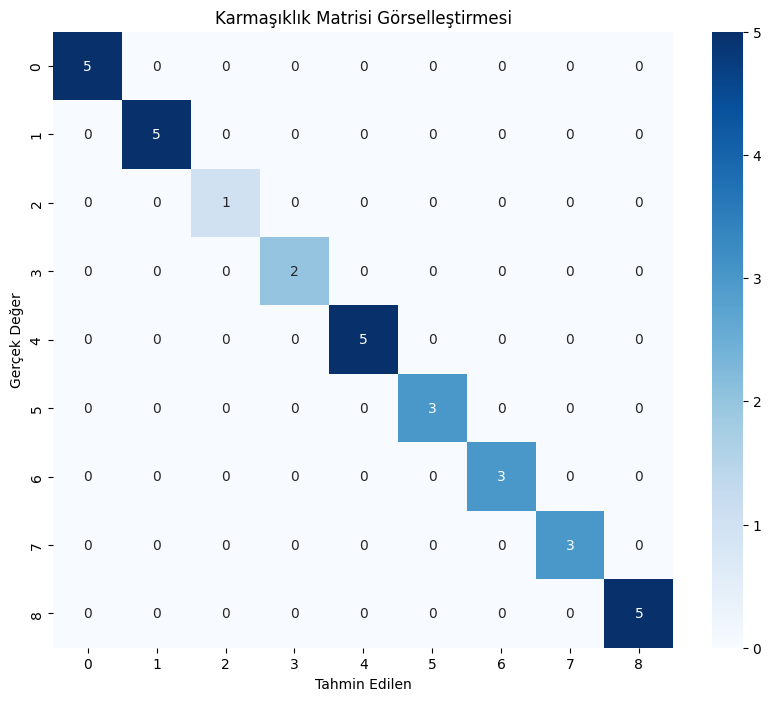

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Karmaşıklık Matrisi Görselleştirmesi')
plt.show()

In [ ]:
!pip install ipycanvas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.4 MB/s eta 0:00:00


In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
import cv2
import numpy as np
from ipywidgets import Button
from ipycanvas import Canvas
from IPython.display import display, clear_output

canvas = Canvas(width=300, height=200, sync_image_data=True)
canvas.line_width = 20
canvas.stroke_style = "black"
canvas.fill_style = "white"
canvas.fill_rect(0, 0, 300, 200)
display(canvas)

drawing = False

def on_mouse_down(x, y):
    global drawing
    drawing = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if drawing:
        canvas.line_to(x, y)
        canvas.stroke()

def on_mouse_up(x, y):
    global drawing
    drawing = False

def predict(key):
    # 1. Canvas'tan RGBA verisini al
    rgba_data = canvas.get_image_data()

    # 2. Grayscale'e çevir (300x200)
    gray = cv2.cvtColor(rgba_data, cv2.COLOR_RGBA2GRAY)

    # 3. 28x28'e yeniden boyutlandır (MNIST formatı)
    resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)

    # 4. Rengi ters çevir: canvas siyah rakam/beyaz arka plan çizer,
    #    MNIST ise beyaz rakam/siyah arka plan kullanır
    resized = 255 - resized

    # 5. [0,1] aralığına normalize et ve tensöre çevir
    tensor = torch.from_numpy(resized).float() / 255.0

    # 6. Eğitimde kullanılan MNIST normalizasyonunu uygula
    tensor = (tensor - 0.1387) / 0.3081

    # 7. (1, 784) şekline getir ve cihaza taşı
    tensor = tensor.view(1, -1)

    # 8. Tahmin yap (eval modu: Dropout kapalı, BatchNorm sabit)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)

    predicted_digit = probs.argmax(dim=1).item()
    confidence      = probs[0, predicted_digit].item() * 100

    clear_output(wait=True)
    display(canvas)
    display(btn)
    print(f"Tahmin    : {predicted_digit}")
    print(f"Güven     : {confidence:.1f}%")
    print(f"Olasılıklar: {[f'{p:.3f}' for p in probs[0].tolist()]}")

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

btn = Button(description='Tahmin Et')
btn.on_click(callback=predict)
display(btn)

Canvas(height=200, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x00\xc8\x08\x06\x00\x…

Button(description='Tahmin Et', style=ButtonStyle())

Tahmin    : 8
Güven     : 44.2%
Olasılıklar: ['0.231', '0.002', '0.018', '0.034', '0.011', '0.170', '0.009', '0.047', '0.442', '0.036']


Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()